In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
df_clean = df.dropna()

print(df_clean.isnull().sum())

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Original Shape: (284807, 31)
Cleaned Shape: (284807, 31)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

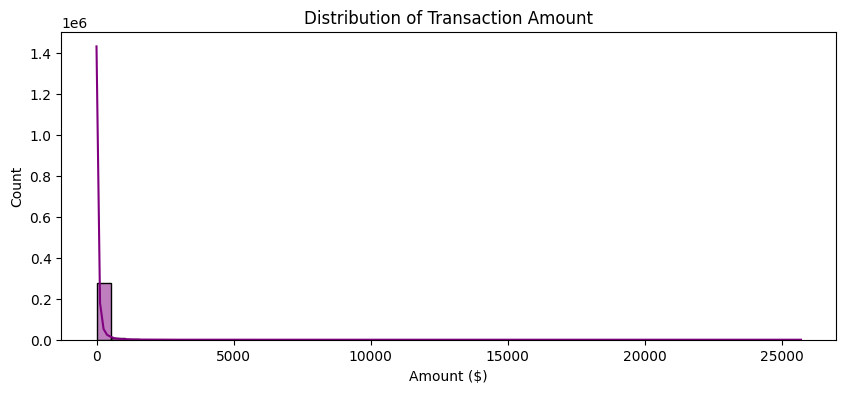

In [7]:
# 1. Figure ka size set karo (Width=10, Height=4)
plt.figure(figsize=(10, 4))

# 2. Amount column ka distribution plot (Histogram) banao
sns.histplot(df_clean['Amount'], bins=50, kde=True, color='purple')

# 3. Graphs par labels lagao
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount ($)')
plt.ylabel('Count')

# 4. Graph ko screen par saaf-saaf dikhao
plt.show()

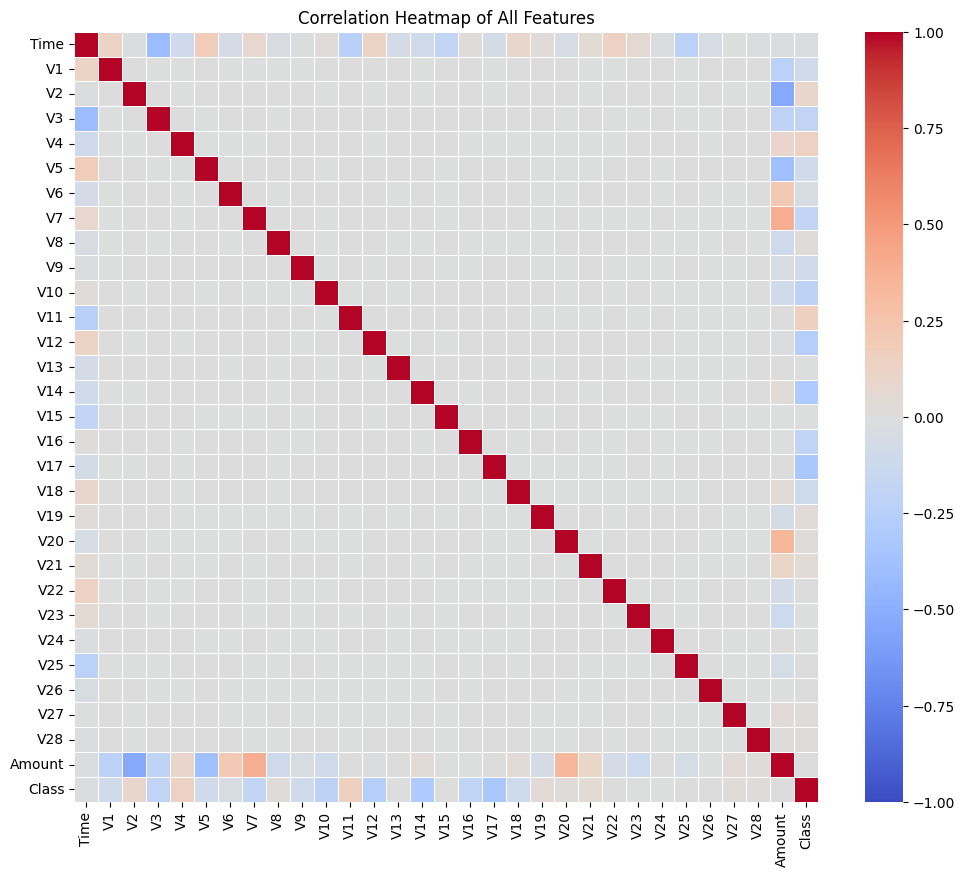

In [8]:
plt.figure(figsize=(12, 10))

corr_matrix = df_clean.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)

plt.title('Correlation Heatmap of All Features')

plt.show()

In [9]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_clean['scaled_amount'] = scaler.fit_transform(df_clean['Amount'].values.reshape(-1,1))
df_clean['scaled_time'] = scaler.fit_transform(df_clean['Time'].values.reshape(-1,1))

df_clean.drop(['Time', 'Amount'], axis=1, inplace=True)

df_clean.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


In [10]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Class', axis=1)

y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (227845, 30)
X_test shape: (56962, 30)


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original X_train shape:", X_train.shape)
print("New Balanced X_train shape:", X_train_res.shape)
print("\nNew Class Distribution in Training Data:")
print(y_train_res.value_counts())

Original X_train shape: (227845, 30)
New Balanced X_train shape: (454902, 30)

New Class Distribution in Training Data:
Class
0    227451
1    227451
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestClassifier
import time

model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

start_time = time.time()

print("Model training shuru ho rahi hai... Thoda sabr rakhein bhai...")
model_rf.fit(X_train_res, y_train_res)

end_time = time.time()

print(f"Mubarak ho bhai! Model perfectly train ho gaya hai.")
print(f"Total Training Time: {round(end_time - start_time, 2)} seconds")

Model training shuru ho rahi hai... Thoda sabr rakhein bhai...
Mubarak ho bhai! Model perfectly train ho gaya hai.
Total Training Time: 340.31 seconds


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_rf.predict(X_test)

print("--- MODEL REPORT CARD ---")
print(classification_report(y_test, y_pred))

--- MODEL REPORT CARD ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.86      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962



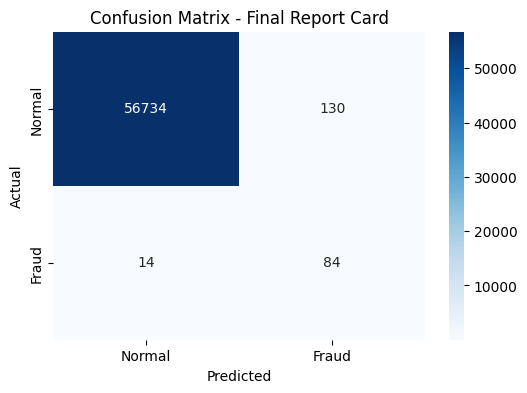

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Report Card')
plt.show()

In [17]:
test_result = X_test.copy()
test_result['Actual_Class'] = y_test
test_result['Predicted_Class'] = y_pred

test_result.to_csv('fraud_predictions_output.csv', index=False)
print("File taiyar hai bhai! Colab ke left panel (Files) se 'fraud_predictions_output.csv' download kar le.")

File taiyar hai bhai! Colab ke left panel (Files) se 'fraud_predictions_output.csv' download kar le.
